# 6.6.1 Fitting time â€” Figure 5 and Supplementary Figure S3
Timings are single recorded model fits on the original machine, excluding shared data preparation. The displayed measurement table preserves those timings. Rerunning measures your machine and need not produce the same seconds.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scripts/models").is_dir())
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from threadpoolctl import threadpool_limits
from scripts.common import core
MODEL_DIR = ROOT / "results/analysis/model_fit"
FIGURES = ROOT / "results/figures"
FIGURES.mkdir(parents=True, exist_ok=True)
payload = core.load_pickle_cross_platform(MODEL_DIR / "models.pkl")

In [2]:
import io
recorded_times = pd.read_csv(io.StringIO('method,fit_time_median_seconds,n_repeats\r\nPairwise empirical semivariogram,0.0620914000028278,1\r\nGH08 semivariogram,0.026838699937798,1\r\nPCA semivariogram,0.3705936999758705,1\r\nKronecker semivariogram,0.0047734000254422,1\r\nLMC semivariogram,0.0184912999975495,1\r\nIOX full semivariogram,13.972691599978134,1\r\nSBSS semivariogram,4.166477299993858,1\r\nMultivariate Matern semivariogram,29.797141199931502,1\r\nPCA MLE,13.699162999982946,1\r\nLMC MLE,527.2404729999835,1\r\n'))
display(recorded_times)

,method,fit_time_median_seconds,n_repeats
0,Pairwise empirical semivariogram,0.062091,1
1,GH08 semivariogram,0.026839,1
2,PCA semivariogram,0.370594,1
3,Kronecker semivariogram,0.004773,1
4,LMC semivariogram,0.018491,1
5,IOX full semivariogram,13.972692,1
6,SBSS semivariogram,4.166477,1
7,Multivariate Matern semivariogram,29.797141,1
8,PCA MLE,13.699163,1
9,LMC MLE,527.240473,1


## Time selected fits
The fitting workflow returns a timing table. Set `RERUN=True` for GH08/PCA semivariogram fits. To time every model, use models=None, method=None; that includes the long LMC MLE fit. `output=None` keeps these test fits in memory.

In [3]:
from scripts.refit import fit_models
RERUN = False
if RERUN:
    with threadpool_limits(limits=1):
        fitted, timings = fit_models(dataset="full", models=["gh08", "pca"], method="semivariogram", output=None)
    display(timings)

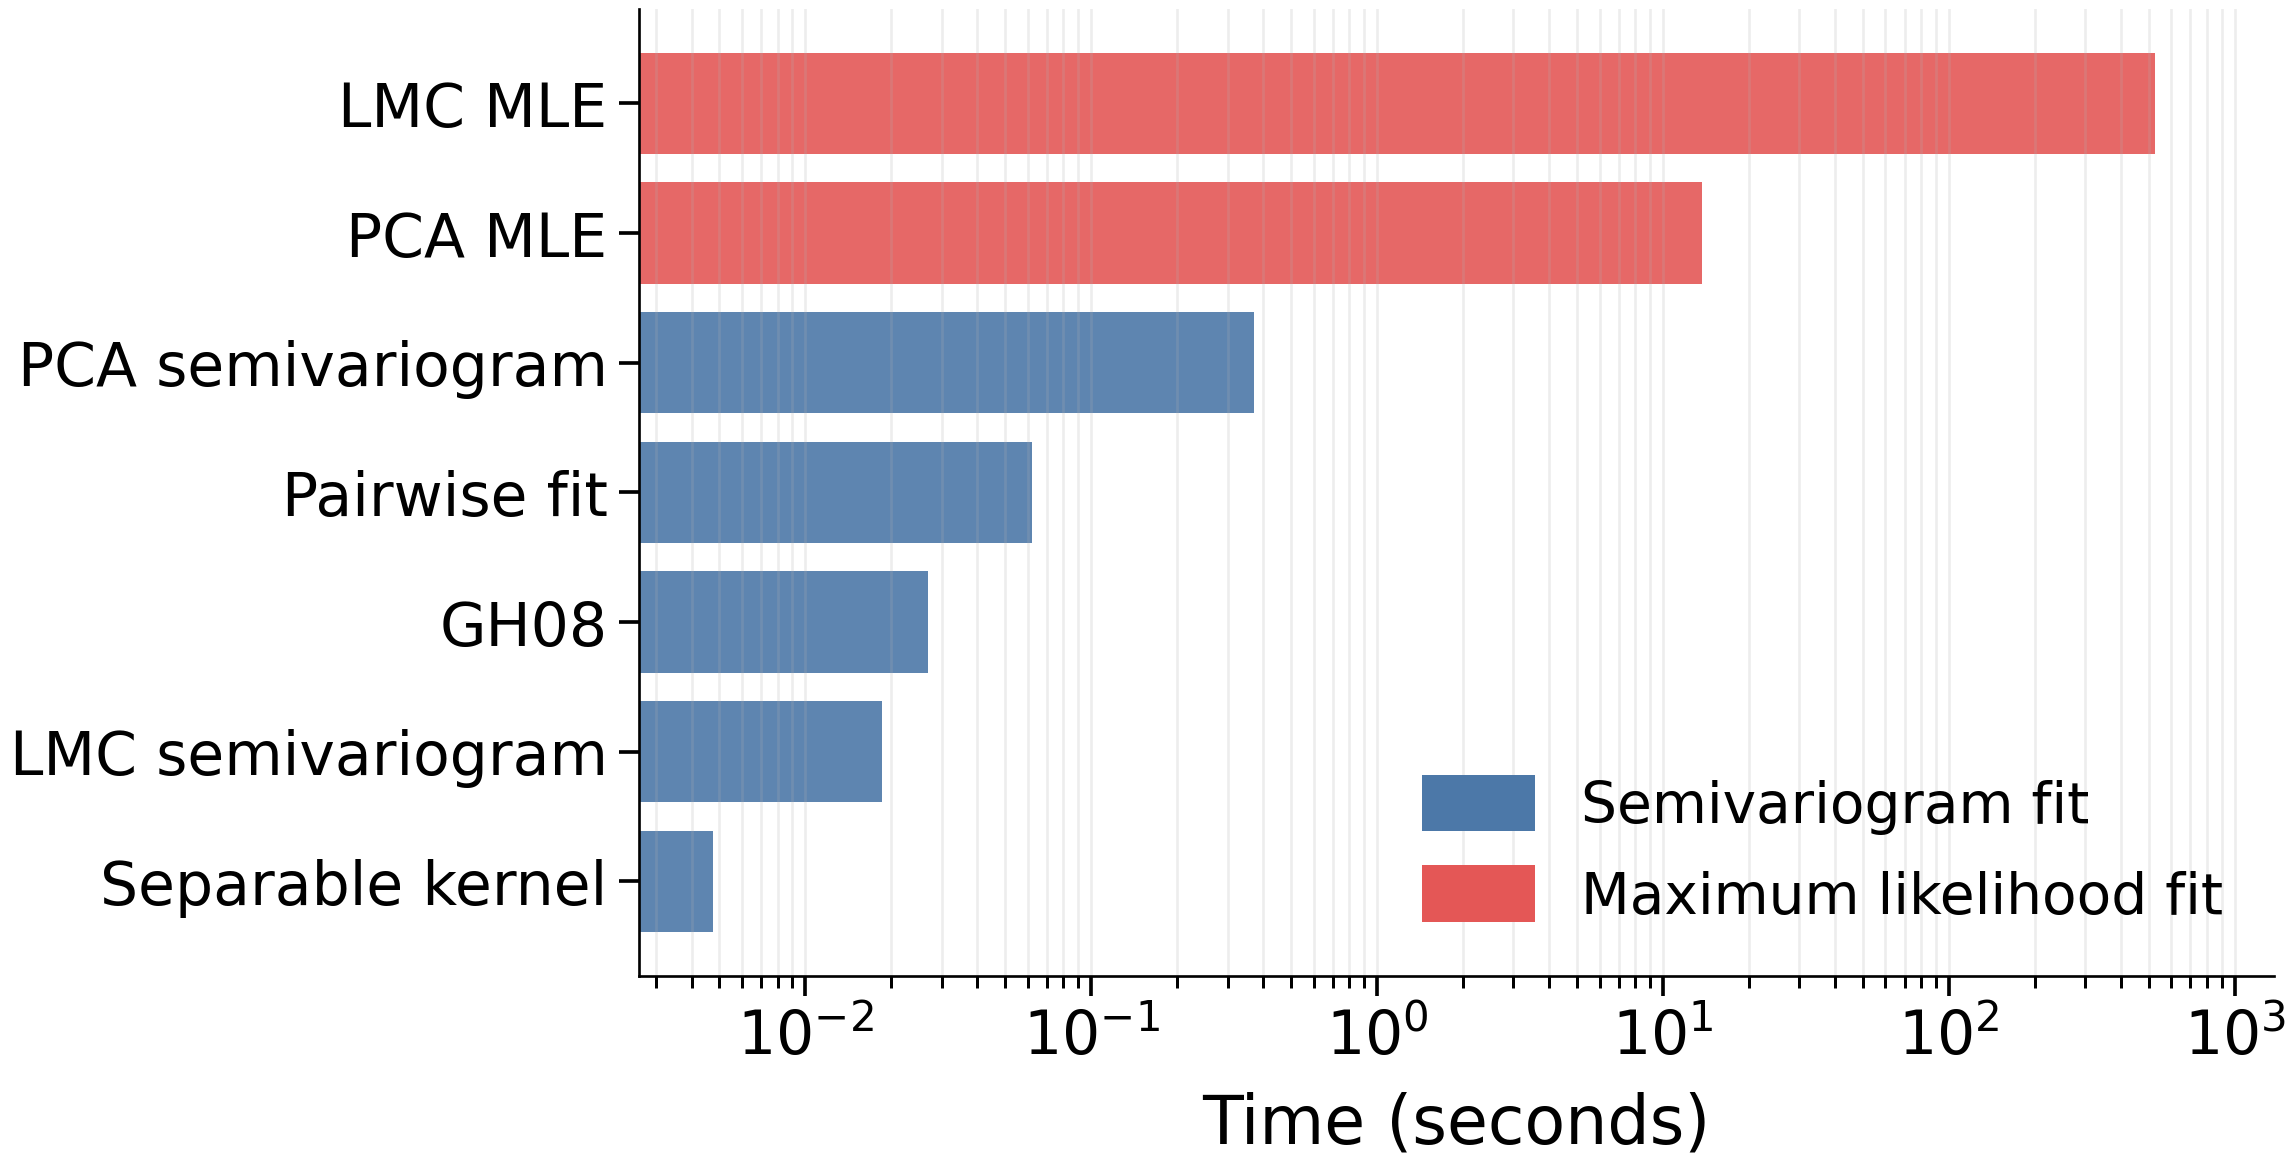

In [4]:
from scripts.common import plotting as p
plot_times = timings.rename(columns={"fit_time_seconds": "fit_time_median_seconds"}).replace({"LMC block MLE": "LMC MLE"}) if RERUN else recorded_times
p.plot_fitting_time(plot_times, FIGURES / "fig05_fitting_time.png")
display(Image(filename=str(FIGURES / "fig05_fitting_time.png")))

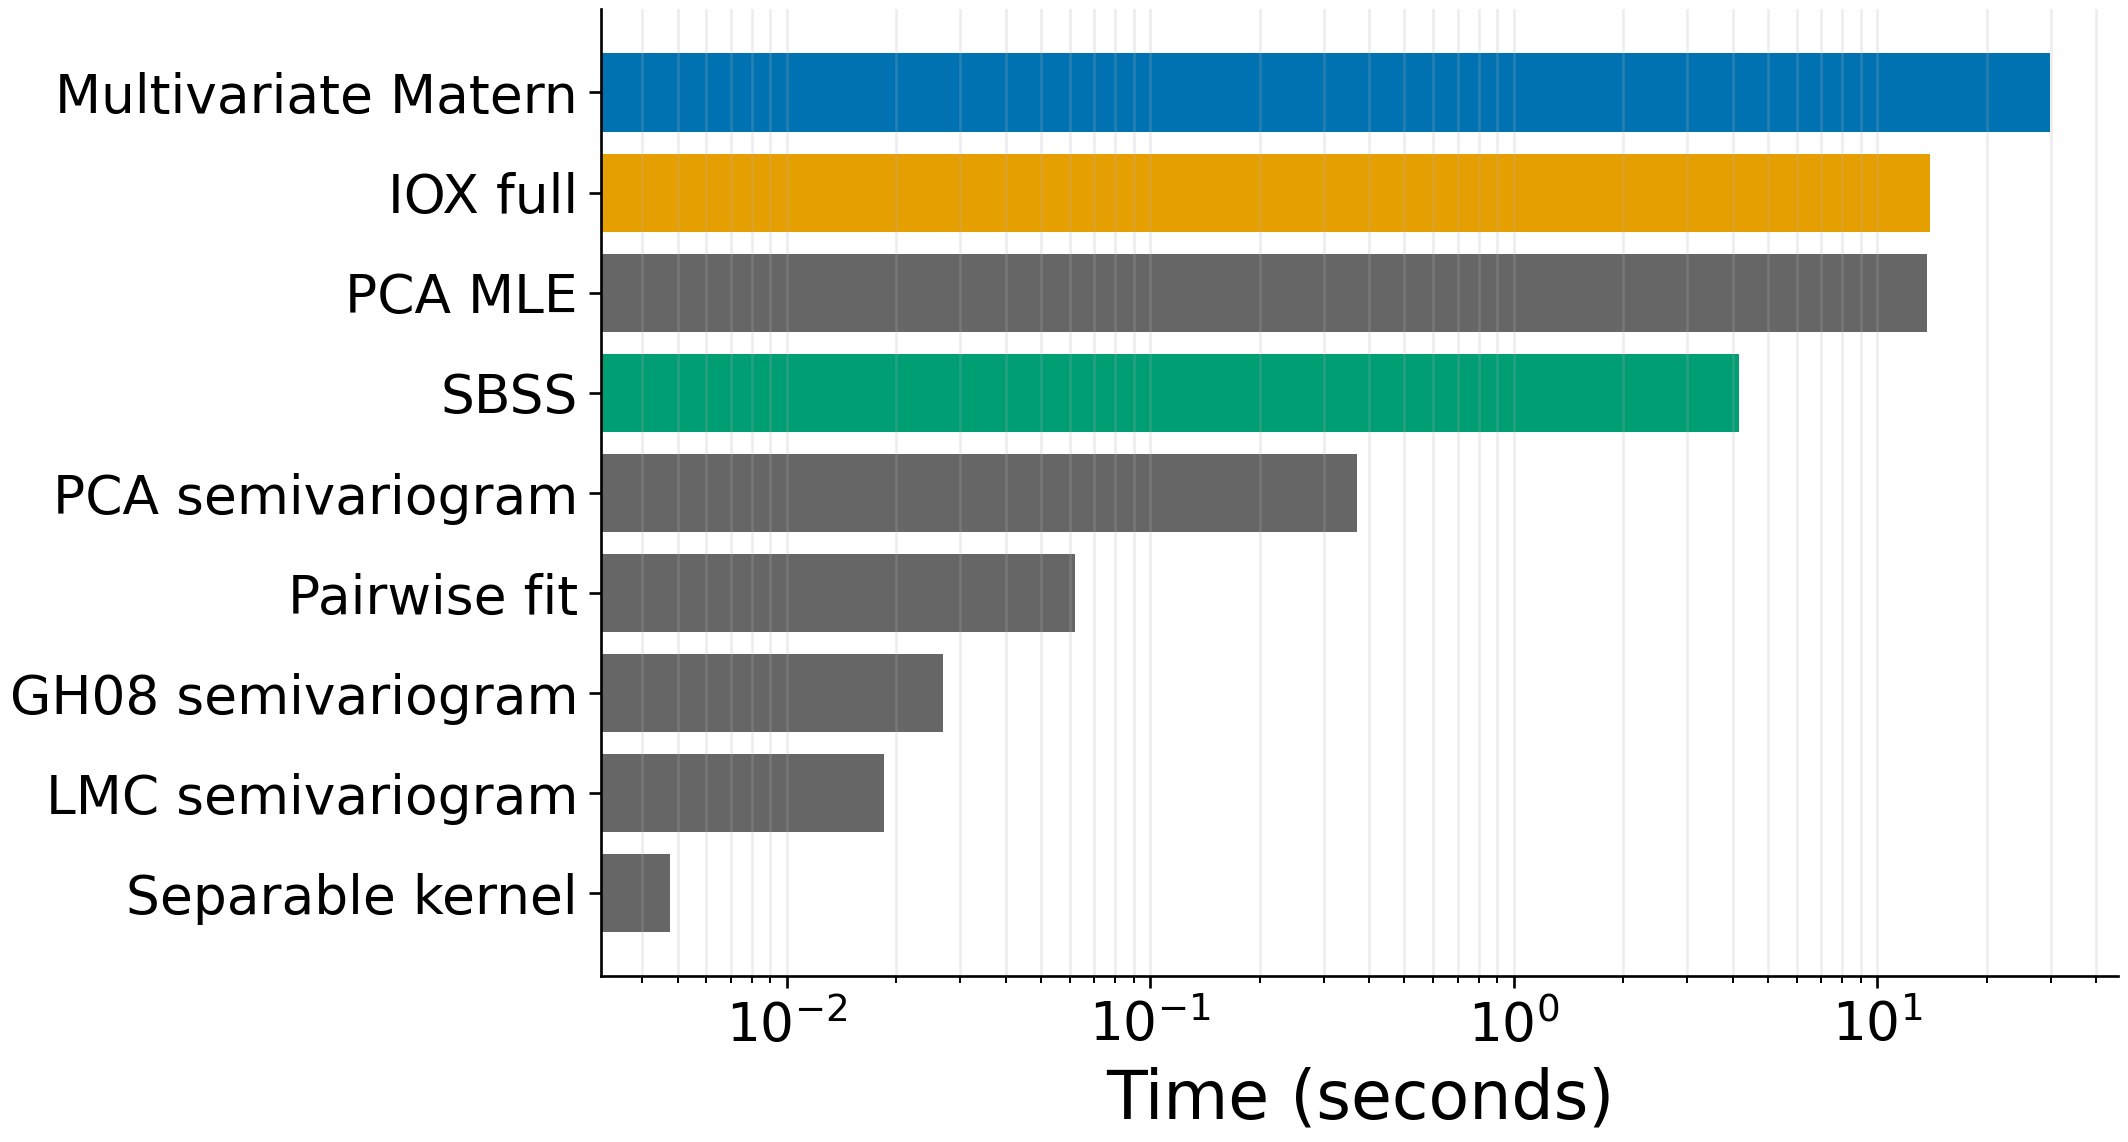

In [5]:
from scripts.analysis.computation.fit_benchmark import supplementary_fit_figure
fig = supplementary_fit_figure(plot_times)
fig.savefig(FIGURES / "figS03_fitting_time.png", dpi=240, bbox_inches="tight", pad_inches=.04)
display(Image(filename=str(FIGURES / "figS03_fitting_time.png")))
plt.close(fig)